In [32]:
import os

print(os.listdir("/content"))

['.config', 'brain_tumor_dataset', 'archive (1).zip', 'sample_data']


In [33]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [34]:
print(os.listdir("/content/brain_tumor_dataset"))

['Training', 'Testing']


In [35]:
print(os.listdir("/content/brain_tumor_dataset/Training"))

['glioma', 'pituitary', 'notumor', 'meningioma']


In [36]:
print(os.listdir("/content/brain_tumor_dataset/Testing"))

['glioma', 'pituitary', 'notumor', 'meningioma']


In [37]:
import os

base_path = "/content/brain_tumor_dataset"

for split in ["Training", "Testing"]:
    print("\n", split)

    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(class_name, ":", count)


 Training
glioma : 1400
pituitary : 1400
notumor : 1400
meningioma : 1400

 Testing
glioma : 400
pituitary : 400
notumor : 400
meningioma : 400


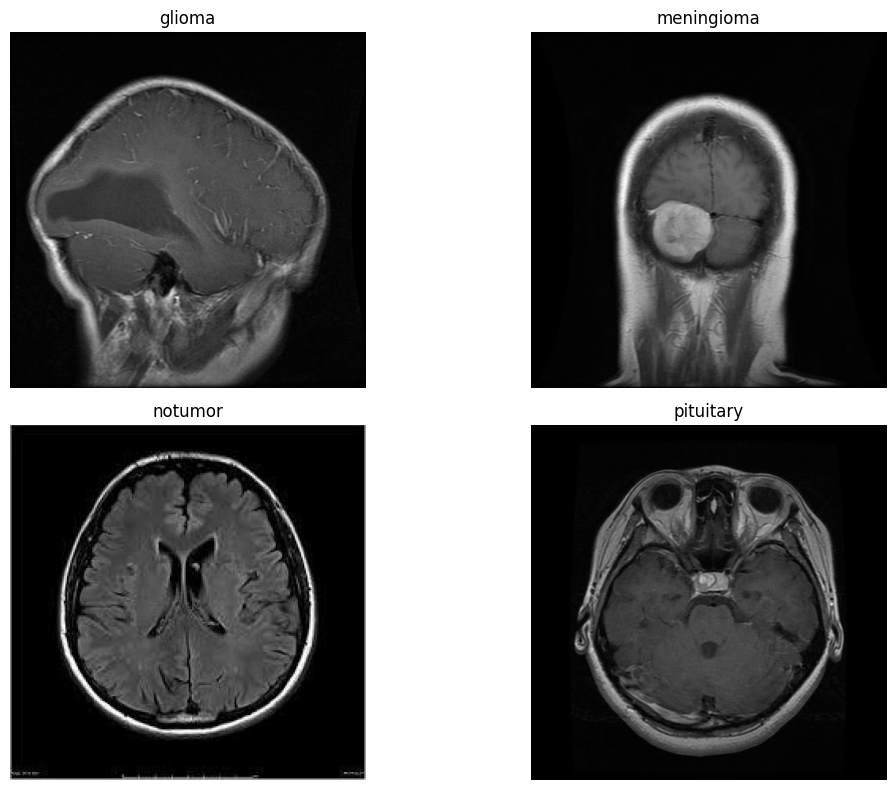

In [38]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

base_path = "/content/brain_tumor_dataset/Training"

classes = ["glioma", "meningioma", "notumor", "pituitary"]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(base_path, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [41]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [42]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [43]:
TRAIN_PATH = "/content/brain_tumor_dataset/Training"
TEST_PATH = "/content/brain_tumor_dataset/Testing"

In [44]:
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training",
    shuffle=True
)

Found 4480 images belonging to 4 classes.


In [45]:
validation_data = validation_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)

Found 1120 images belonging to 4 classes.


In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("test_datagen created successfully")

test_datagen created successfully


In [47]:
test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [48]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [53]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Classification
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 4 output classes
    layers.Dense(4, activation="softmax")
])
print("CNN model created successfully!")

CNN model created successfully!


In [54]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_brain_tumor_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [58]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 448ms/step - accuracy: 0.8513 - loss: 0.3990 - val_accuracy: 0.8357 - val_loss: 0.4435 - learning_rate: 8.0000e-06
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 445ms/step - accuracy: 0.8520 - loss: 0.3926 - val_accuracy: 0.8313 - val_loss: 0.4456 - learning_rate: 8.0000e-06
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 439ms/step - accuracy: 0.8556 - loss: 0.3842 - val_accuracy: 0.8295 - val_loss: 0.4484 - learning_rate: 1.6000e-06
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 446ms/step - accuracy: 0.8605 - loss: 0.3869 - val_accuracy: 0.8339 - val_loss: 0.4432 - learning_rate: 1.6000e-06
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 442ms/step - accuracy: 0.8489 - loss: 0.4010 - val_accuracy: 0.8321 - val_loss: 0.4433 - learning_rate: 1.0000e-06


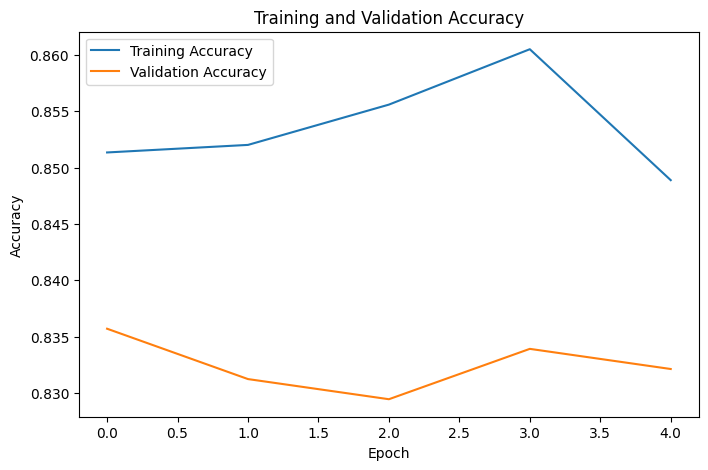

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

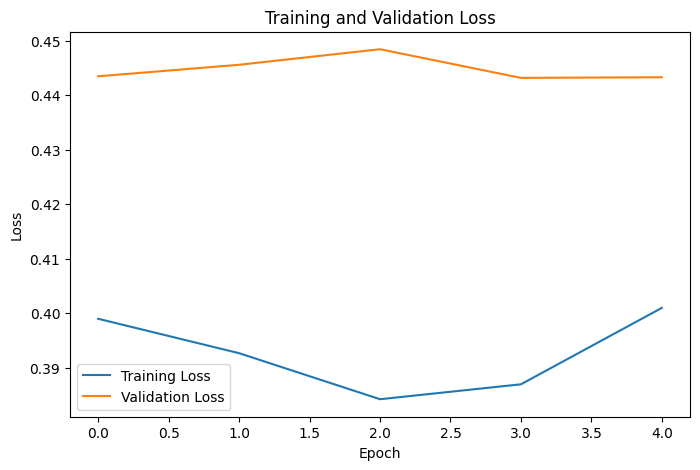

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()